In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

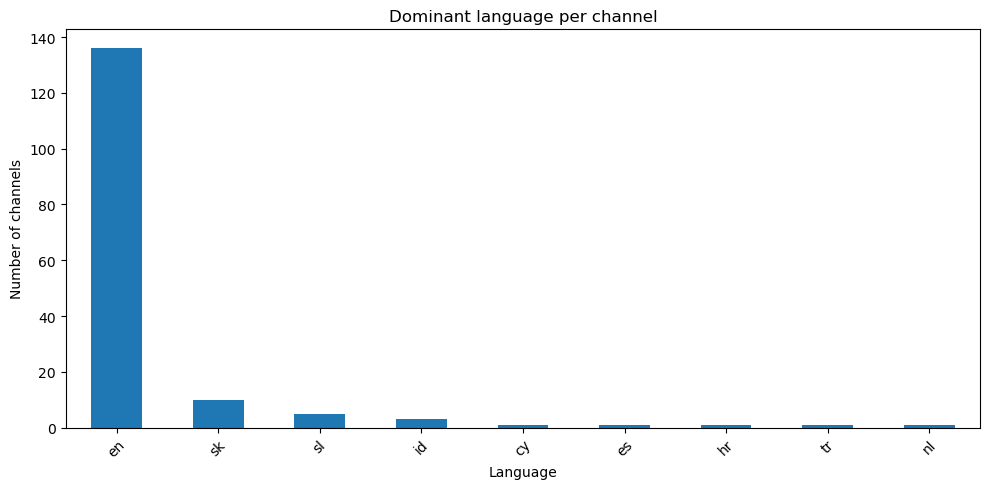

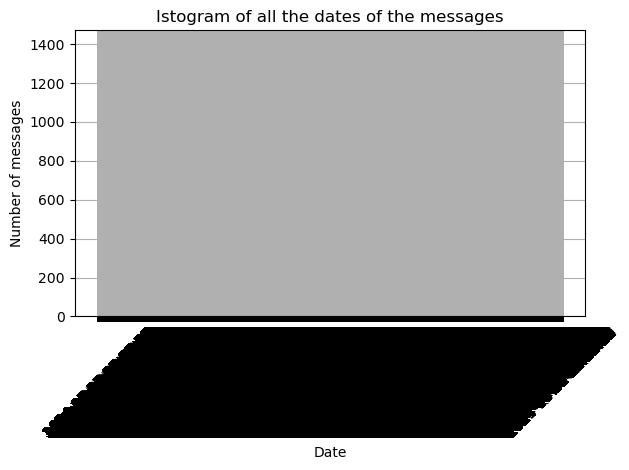

Numero di testi pre-processati: 154473
---
Numero di canali unici: 150
---


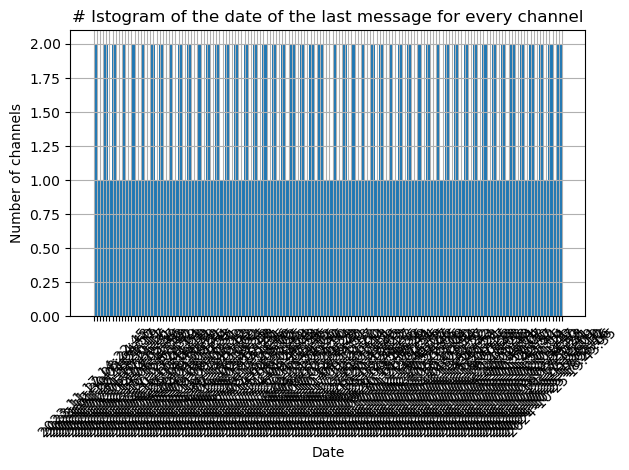

In [2]:

df_preprocessed_non_empty_channels = pd.read_csv(
    "../material/preprocessed_messages.tsv.gz", 
    sep='\t', 
    compression='gzip'
)

df_english_preprocessed_non_empty_channels = pd.read_csv(
    "../material/preprocessed_english_messages.tsv.gz", 
    sep='\t', 
    compression='gzip'
)

# Group by channel_id and language, count the number of messages
lang_counts = df_preprocessed_non_empty_channels.groupby(['channel_id', 'language']).size().reset_index(name='count')

# Sort by channel_id and message count in descending order
lang_counts_sorted = lang_counts.sort_values(['channel_id', 'count'], ascending=[True, False])

# Keep only the most frequent language for each channel
dominant_lang = lang_counts_sorted.drop_duplicates(subset='channel_id', keep='first')

# Plot the distribution of dominant languages
plt.figure(figsize=(10, 5))
dominant_lang['language'].value_counts().plot(kind='bar')
plt.title("Dominant language per channel")
plt.xlabel("Language")
plt.ylabel("Number of channels")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Istogram of all the dates of the messages
df_english_preprocessed_non_empty_channels['date'].hist(bins=120)
plt.title("Istogram of all the dates of the messages")
plt.xlabel("Date")
plt.ylabel("Number of messages")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Numero di testi pre-processati:", len(df_english_preprocessed_non_empty_channels['text_preprocessed']))
print("---")
print("Numero di canali unici:", df_english_preprocessed_non_empty_channels['channel_id'].nunique())
print("---")

# Istogram of the date of the last message for every channel
df_english_preprocessed_non_empty_channels.sort_values(by='date') \
    .drop_duplicates(subset='channel_id', keep='last')['date'] \
    .hist(bins=100)
plt.title("# Istogram of the date of the last message for every channel")
plt.xlabel("Date")
plt.ylabel("Number of channels")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
